In [1]:
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from battleship.scoring import compute_score, compute_score_parallel
from battleship.prompting import HUMAN_DATASET_PATH
from battleship.board import Board

# Configure matplotlib for retina display
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Configure seaborn
sns.set_theme(style="whitegrid")

In [2]:
RESULTS_DIR = "results_official"

# Load the data

In [3]:
HUMAN_DATA_PATH = os.path.join(RESULTS_DIR, "human_question_dataset_scored.csv")

# Compute scores if they don't exist
if not os.path.exists(HUMAN_DATA_PATH):
    df_human = pd.read_csv(HUMAN_DATASET_PATH)
    df_human["score"] = [
        compute_score(program=program, board=Board.from_trial_id(trial_id))
        for program, trial_id in zip(df_human["code"], df_human["trial"])
    ]
    df_human["model"] = "Human"
    df_human.to_csv(HUMAN_DATA_PATH, index=False)
else:
    df_human = pd.read_csv(HUMAN_DATA_PATH)

df_human = df_human.rename(columns={"trial": "trial_id", "code": "program"})
df_human

,trial_id,question,program,score,model
0,1,Are all ships horizontal?,(all (map (lambda x0 (== (orient x0) H)) (set ...,0.470937,Human
1,1,Are any of the ships touching?,(or (or (touch Blue Purple) (touch Purple Red)...,0.988805,Human
2,1,Are any ships 2 tiles long?,(any (map (lambda x0 (== (size x0) 2)) (set Al...,0.378446,Human
3,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human
4,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human
...,...,...,...,...,...
600,18,Is there a purple tile at 1A?,(== (color 1A) Purple),0.954434,Human
601,18,Is there a purple tile at 2C?,(== (color 2C) Purple),0.811278,Human
602,18,Is there any part of the purple ship in column B?,(any (map (lambda y0 (== (colL y0) 2)) (colore...,0.954434,Human
603,18,What color is at 1A?,(color 1A),0.954434,Human


In [4]:
df_codellama_7b = pd.read_csv(os.path.join(RESULTS_DIR, "CodeLlama-7b-hf-2024-01-23-04-52-40", "results_corrected.csv"))
df_codellama_7b["model"] = "CodeLlama-7b"
# rename completion -> question and translation -> program
df_codellama_7b = df_codellama_7b.rename(columns={"completion": "question", "translation": "program"})
df_codellama_7b

,trial_id,question,program,score,type,prompt_id,model
0,1,How many tiles is the purple ship?,(size Purple),1.360775,final,0,CodeLlama-7b
1,1,What color is at 2F?,(color 2F),1.418245,final,0,CodeLlama-7b
2,1,Is the red ship horizontal?,(== (orient Red) H),0.993542,final,0,CodeLlama-7b
3,1,Is there a water tile at 3D?,(== (color 3D) Water),-0.000000,final,0,CodeLlama-7b
4,1,Is there a ship at 2F?,(color 2F),1.418245,final,0,CodeLlama-7b
...,...,...,...,...,...,...,...
1795,18,What color is at 1B?,(at 1 B),NaN,final,19,CodeLlama-7b
1796,18,Is the purple ship 4 tiles long?,(== (size Purple) 4),0.811278,final,19,CodeLlama-7b
1797,18,What color is at 5B?,(at 5B),NaN,final,19,CodeLlama-7b
1798,18,How many tiles is the blue ship?,(size Blue),-0.000000,final,19,CodeLlama-7b


In [5]:
# df_gpt4 = pd.read_csv(os.path.join(RESULTS_DIR, "gpt4-2024-01-23-21-53-34", "results.csv"))
df_gpt4 = pd.read_csv(os.path.join(RESULTS_DIR, "gpt4-2024-01-25-15-02-02", "results.csv"))

df_gpt4["model"] = "GPT-4"
df_gpt4

,trial_id,prompt_id,question,program,score,model
0,1,0,Is there a red tile at 4B?,(== (color 4B) Red),0.526992,GPT-4
1,1,0,Is there a blue tile at 2D?,(== (color 2D) Blue),0.276876,GPT-4
2,1,0,Is there a purple tile at 1A?,(== (color 1A) Purple),0.388128,GPT-4
3,1,0,Is there a ship at 4B?,(exists (color 4B)),NaN,GPT-4
4,1,0,Is there a red tile at 1B?,(== (color 1B) Red),0.499458,GPT-4
...,...,...,...,...,...,...
1795,18,19,Is the red ship horizontal?,(== (orient Red) H),-0.000000,GPT-4
1796,18,19,Is the red ship vertical?,(== (orient Red) V),-0.000000,GPT-4
1797,18,19,How many tiles is the red ship?,(size Red),-0.000000,GPT-4
1798,18,19,Is the purple ship 4 tiles long?,(== (size Purple) 4),0.811278,GPT-4


In [23]:
df_grammar_sampling = pd.read_csv(os.path.join(RESULTS_DIR, "grammar-sampling-2024-01-22", "sampling_data.csv"))
df_grammar_sampling = df_grammar_sampling.rename(columns={"board_id": "trial_id"})
df_grammar_sampling = df_grammar_sampling[["trial_id", "program", "score", "depth"]]
df_grammar_sampling["model"] = "Grammar (sampling)"

# # Pretend that we only sampled 100 programs per trial
# df_grammar_sampling = df_grammar_sampling.groupby("trial_id").head(100)

df_grammar_sampling

,trial_id,program,score,depth,model
0,1,( not ( == ( + ( == 0 1 ) ( or TRUE ( == ( == ...,-0.000000,8,Grammar (sampling)
1,1,( and ( == 4 ( - ( colL 5C ) 1 ) ) ( or ( == V...,-0.000000,5,Grammar (sampling)
2,1,( + ( == ( + 2 ( size Red ) ) 3 ) ( == H ( ori...,0.993542,5,Grammar (sampling)
3,1,( < ( + ( touch Red Blue ) TRUE ) ( + ( rowL 1...,0.756291,11,Grammar (sampling)
4,1,( == ( and ( == ( color 4A ) Water ) ( > ( col...,-0.000000,5,Grammar (sampling)
...,...,...,...,...,...
1799995,18,( + ( and ( touch Blue Red ) ( == 4 ( colL 5F ...,-0.000000,9,Grammar (sampling)
1799996,18,( - ( setSize ( coloredTiles Water ) ) ( + ( =...,1.561278,9,Grammar (sampling)
1799997,18,( and ( or ( or FALSE ( and ( == H ( orient Pu...,-0.000000,12,Grammar (sampling)
1799998,18,( setSize ( intersection ( intersection ( setD...,-0.000000,7,Grammar (sampling)


In [24]:
df_grammar_enumeration = pd.read_csv(os.path.join(RESULTS_DIR, "grammar-enumeration-2024-01-22", "enumeration_data.csv"))
df_grammar_enumeration = df_grammar_enumeration.rename(columns={"board_id": "trial_id"})
df_grammar_enumeration = df_grammar_enumeration[["trial_id", "program", "score"]]
df_grammar_enumeration["model"] = "Grammar (enumeration)"

# # Pretend that we only sampled 100 programs per trial
# df_grammar_enumeration = df_grammar_enumeration.groupby("trial_id").head(100)

df_grammar_enumeration

,trial_id,program,score,model
0,1,TRUE,-0.0,Grammar (enumeration)
1,1,FALSE,-0.0,Grammar (enumeration)
2,1,( not TRUE ),-0.0,Grammar (enumeration)
3,1,( not FALSE ),-0.0,Grammar (enumeration)
4,1,( not ( not TRUE ) ),-0.0,Grammar (enumeration)
...,...,...,...,...
1799995,18,( and ( < 8 0 ) ( == 1 5 ) ),-0.0,Grammar (enumeration)
1799996,18,( and ( < 8 0 ) ( == 1 6 ) ),-0.0,Grammar (enumeration)
1799997,18,( and ( < 8 0 ) ( == 1 7 ) ),-0.0,Grammar (enumeration)
1799998,18,( and ( < 8 0 ) ( == 1 8 ) ),-0.0,Grammar (enumeration)


# Construct bootstrapped k samples

In [25]:
BOOTSTRAP_MODELS = [df_codellama_7b, df_gpt4, df_grammar_sampling, df_grammar_enumeration]


def bootstrap(df: pd.DataFrame, k: int = 5):
    """Splits the data into chunks of size k and returns the single highest-scoring row from each chunk."""
    # samples = []
    # for chunk in range(0, len(df), k):
    #     samples.append(df.iloc[chunk:chunk+k].nlargest(1, "score"))
    # return pd.concat(samples).reset_index(drop=False)
    _scores = df["score"].to_numpy()
    n = len(_scores)
    _scores = np.nan_to_num(_scores, nan=float('-inf'))
    _scores = np.reshape(_scores, (-1, k))
    idx = np.argmax(_scores, axis=1)
    offset = np.array([i * k for i in range(len(idx))])
    idx = idx + offset
    _df = df.iloc[idx].reset_index(drop=True)
    return _df

data = []

for _df_model in BOOTSTRAP_MODELS:
    # k=1
    _df = _df_model
    _df["k"] = 1
    data.append(_df)
    # k > 1
    for k in [5, 10, 20, 50, 100]:
        # _df = _df_model.groupby(["model", "trial_id"]).apply(lambda df: bootstrap(df, k=k)).reset_index(drop=True)
        for trial_id, df_group in _df_model.groupby("trial_id"):
            _df = bootstrap(df_group.copy(), k=k)
            _df["k"] = k
            data.append(_df)

df_bootstrapped = pd.concat(data).reset_index(drop=True)
df_bootstrapped

,trial_id,question,program,score,type,prompt_id,model,k,depth
0,1,How many tiles is the purple ship?,(size Purple),1.360775,final,0.0,CodeLlama-7b,1,NaN
1,1,What color is at 2F?,(color 2F),1.418245,final,0.0,CodeLlama-7b,1,NaN
2,1,Is the red ship horizontal?,(== (orient Red) H),0.993542,final,0.0,CodeLlama-7b,1,NaN
3,1,Is there a water tile at 3D?,(== (color 3D) Water),-0.000000,final,0.0,CodeLlama-7b,1,NaN
4,1,Is there a ship at 2F?,(color 2F),1.418245,final,0.0,CodeLlama-7b,1,NaN
...,...,...,...,...,...,...,...,...,...
4972963,18,NaN,( and ( < 7 8 ) ( > 7 7 ) ),-0.000000,NaN,NaN,Grammar (enumeration),100,NaN
4972964,18,NaN,( and ( < 7 8 ) ( touch Blue Purple ) ),0.811278,NaN,NaN,Grammar (enumeration),100,NaN
4972965,18,NaN,( and ( < 7 9 ) ( == 5 1 ) ),-0.000000,NaN,NaN,Grammar (enumeration),100,NaN
4972966,18,NaN,( and ( < 7 9 ) ( > 4 6 ) ),-0.000000,NaN,NaN,Grammar (enumeration),100,NaN


# Merge datasets

In [26]:
df = pd.concat([df_human, df_bootstrapped]).reset_index(drop=True)
# df = pd.concat([df_human, df_codellama_7b, df_gpt4, df_grammar_sampling, df_grammar_enumeration]).reset_index(drop=True)
df["k"] = df["k"].fillna(1).astype(int)
df

,trial_id,question,program,score,model,type,prompt_id,k,depth
0,1,Are all ships horizontal?,(all (map (lambda x0 (== (orient x0) H)) (set ...,0.470937,Human,NaN,NaN,1,NaN
1,1,Are any of the ships touching?,(or (or (touch Blue Purple) (touch Purple Red)...,0.988805,Human,NaN,NaN,1,NaN
2,1,Are any ships 2 tiles long?,(any (map (lambda x0 (== (size x0) 2)) (set Al...,0.378446,Human,NaN,NaN,1,NaN
3,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human,NaN,NaN,1,NaN
4,1,At what location is the top left part of the r...,(topleft (coloredTiles Red)),4.669496,Human,NaN,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...
4973568,18,NaN,( and ( < 7 8 ) ( > 7 7 ) ),-0.000000,Grammar (enumeration),NaN,NaN,100,NaN
4973569,18,NaN,( and ( < 7 8 ) ( touch Blue Purple ) ),0.811278,Grammar (enumeration),NaN,NaN,100,NaN
4973570,18,NaN,( and ( < 7 9 ) ( == 5 1 ) ),-0.000000,Grammar (enumeration),NaN,NaN,100,NaN
4973571,18,NaN,( and ( < 7 9 ) ( > 4 6 ) ),-0.000000,Grammar (enumeration),NaN,NaN,100,NaN


# EIG comparison

### Summary stats

In [44]:
aggregators = {
    "mean": "mean",
    # "max": "max",
    "valid": lambda x: x.count() / len(x),
    "nonzero": lambda x: (x > 0).sum() / len(x),
    "count": lambda x: len(x),
}

In [45]:
df_grouped_by_model = df.groupby(["model", "k"]).score.agg(**aggregators)
df_grouped_by_model

mean     valid   nonzero    count
model                 k                                         
CodeLlama-7b          1    0.652393  0.746667  0.446667     1800
                      5    1.238703  0.988889  0.902778      360
                      10   1.547547  0.994444  0.972222      180
                      20   1.833006  1.000000  1.000000       90
                      50   2.307543  1.000000  1.000000       36
                      100  2.759962  1.000000  1.000000       18
GPT-4                 1    0.771317  0.877222  0.589444     1800
                      5    1.161580  0.980556  0.863889      360
                      10   1.432370  1.000000  0.966667      180
                      20   1.647637  1.000000  1.000000       90
                      50   2.035265  1.000000  1.000000       36
                      100  2.285493  1.000000  1.000000       18
Grammar (enumeration) 1    0.003454  1.000000  0.004933  1800000
                      5    0.008466  1.000000  0.011039   360000
                      10   0.012797  1.000000  0.016339   180000
                      20   0.021840  1.000000  0.027500    90000
                      50   0.047170  1.000000  0.058444    36000
                      100  0.089967  1.000000  0.110889    18000
Grammar (sampling)    1    0.251079  1.000000  0.238037  1800000
                      5    0.905448  1.000000  0.731686   360000
                      10   1.337298  1.000000  0.920839   180000
                      20   1.777363  1.000000  0.990678    90000
                      50   2.333816  1.000000  0.999889    36000
                      100  2.695215  1.000000  1.000000    18000
Human                 1    1.268045  1.000000  0.966942      605

In [46]:
df_grouped_by_trial = df.groupby(["trial_id", "model", "k"]).score.agg(**aggregators)
df_grouped_by_trial

mean  valid   nonzero  count
trial_id model              k                                    
1        CodeLlama-7b       1    1.122182   0.72  0.620000    100
                            5    1.730785   1.00  1.000000     20
                            10   2.373790   1.00  1.000000     10
                            20   2.725061   1.00  1.000000      5
                            50   4.669496   1.00  1.000000      2
...                                   ...    ...       ...    ...
18       Grammar (sampling) 10   0.892799   1.00  0.732900  10000
                            20   1.243118   1.00  0.927600   5000
                            50   1.596501   1.00  0.998000   2000
                            100  1.800325   1.00  1.000000   1000
         Human              1    1.078188   1.00  0.972222     36

[450 rows x 4 columns]

In [47]:
df_main_results = df_grouped_by_trial.groupby(["model", "k"])[list(aggregators.keys())].agg(["mean", "std"])
# flatten multiindex
df_main_results.columns = [col[1] if col[1] == "std" else col[0] for col in df_main_results.columns]
df_main_results = df_main_results.round(3)
df_main_results

mean    std  valid    std  nonzero    std  \
model                 k                                                 
CodeLlama-7b          1    0.657  0.237  0.747  0.037    0.447  0.122   
                      5    1.242  0.291  0.989  0.027    0.903  0.087   
                      10   1.549  0.366  0.994  0.024    0.972  0.046   
                      20   1.833  0.460  1.000  0.000    1.000  0.000   
                      50   2.308  0.941  1.000  0.000    1.000  0.000   
                      100  2.760  1.287  1.000  0.000    1.000  0.000   
GPT-4                 1    0.782  0.337  0.877  0.082    0.589  0.231   
                      5    1.163  0.355  0.981  0.025    0.864  0.185   
                      10   1.432  0.372  1.000  0.000    0.967  0.077   
                      20   1.648  0.451  1.000  0.000    1.000  0.000   
                      50   2.035  0.962  1.000  0.000    1.000  0.000   
                      100  2.285  1.311  1.000  0.000    1.000  0.000   
Grammar (enumeration) 1    0.003  0.001  1.000  0.000    0.005  0.002   
                      5    0.008  0.003  1.000  0.000    0.011  0.003   
                      10   0.013  0.004  1.000  0.000    0.016  0.004   
                      20   0.022  0.006  1.000  0.000    0.028  0.007   
                      50   0.047  0.014  1.000  0.000    0.058  0.015   
                      100  0.090  0.026  1.000  0.000    0.111  0.028   
Grammar (sampling)    1    0.251  0.057  1.000  0.000    0.238  0.051   
                      5    0.905  0.160  1.000  0.000    0.732  0.092   
                      10   1.337  0.202  1.000  0.000    0.921  0.058   
                      20   1.777  0.253  1.000  0.000    0.991  0.017   
                      50   2.334  0.356  1.000  0.000    1.000  0.000   
                      100  2.695  0.439  1.000  0.000    1.000  0.000   
Human                 1    1.274  0.172  1.000  0.000    0.966  0.028   

                                count    std  
model                 k                       
CodeLlama-7b          1       100.000  0.000  
                      5        20.000  0.000  
                      10       10.000  0.000  
                      20        5.000  0.000  
                      50        2.000  0.000  
                      100       1.000  0.000  
GPT-4                 1       100.000  0.000  
                      5        20.000  0.000  
                      10       10.000  0.000  
                      20        5.000  0.000  
                      50        2.000  0.000  
                      100       1.000  0.000  
Grammar (enumeration) 1    100000.000  0.000  
                      5     20000.000  0.000  
                      10    10000.000  0.000  
                      20     5000.000  0.000  
                      50     2000.000  0.000  
                      100    1000.000  0.000  
Grammar (sampling)    1    100000.000  0.000  
                      5     20000.000  0.000  
                      10    10000.000  0.000  
                      20     5000.000  0.000  
                      50     2000.000  0.000  
                      100    1000.000  0.000  
Human                 1        33.611  3.632

In [48]:
df_main_results.reset_index()

,model,k,mean,std,valid,std,nonzero,std,count,std
0,CodeLlama-7b,1,0.657,0.237,0.747,0.037,0.447,0.122,100.000,0.000
1,CodeLlama-7b,5,1.242,0.291,0.989,0.027,0.903,0.087,20.000,0.000
2,CodeLlama-7b,10,1.549,0.366,0.994,0.024,0.972,0.046,10.000,0.000
3,CodeLlama-7b,20,1.833,0.460,1.000,0.000,1.000,0.000,5.000,0.000
4,CodeLlama-7b,50,2.308,0.941,1.000,0.000,1.000,0.000,2.000,0.000
5,CodeLlama-7b,100,2.760,1.287,1.000,0.000,1.000,0.000,1.000,0.000
6,GPT-4,1,0.782,0.337,0.877,0.082,0.589,0.231,100.000,0.000
7,GPT-4,5,1.163,0.355,0.981,0.025,0.864,0.185,20.000,0.000
8,GPT-4,10,1.432,0.372,1.000,0.000,0.967,0.077,10.000,0.000
9,GPT-4,20,1.648,0.451,1.000,0.000,1.000,0.000,5.000,0.000


In [51]:
# convert to markdown
print(df_main_results.reset_index().to_markdown())

|    | model                 |   k |   mean |   std |   valid |   std |   nonzero |   std |      count |   std |
|---:|:----------------------|----:|-------:|------:|--------:|------:|----------:|------:|-----------:|------:|
|  0 | CodeLlama-7b          |   1 |  0.657 | 0.237 |   0.747 | 0.037 |     0.447 | 0.122 |    100     | 0     |
|  1 | CodeLlama-7b          |   5 |  1.242 | 0.291 |   0.989 | 0.027 |     0.903 | 0.087 |     20     | 0     |
|  2 | CodeLlama-7b          |  10 |  1.549 | 0.366 |   0.994 | 0.024 |     0.972 | 0.046 |     10     | 0     |
|  3 | CodeLlama-7b          |  20 |  1.833 | 0.46  |   1     | 0     |     1     | 0     |      5     | 0     |
|  4 | CodeLlama-7b          |  50 |  2.308 | 0.941 |   1     | 0     |     1     | 0     |      2     | 0     |
|  5 | CodeLlama-7b          | 100 |  2.76  | 1.287 |   1     | 0     |     1     | 0     |      1     | 0     |
|  6 | GPT-4                 |   1 |  0.782 | 0.337 |   0.877 | 0.082 |     0.589 | 0.231 |    1

### Overall EIG distributions

In [33]:
df_1 = df[df["k"] == 1]

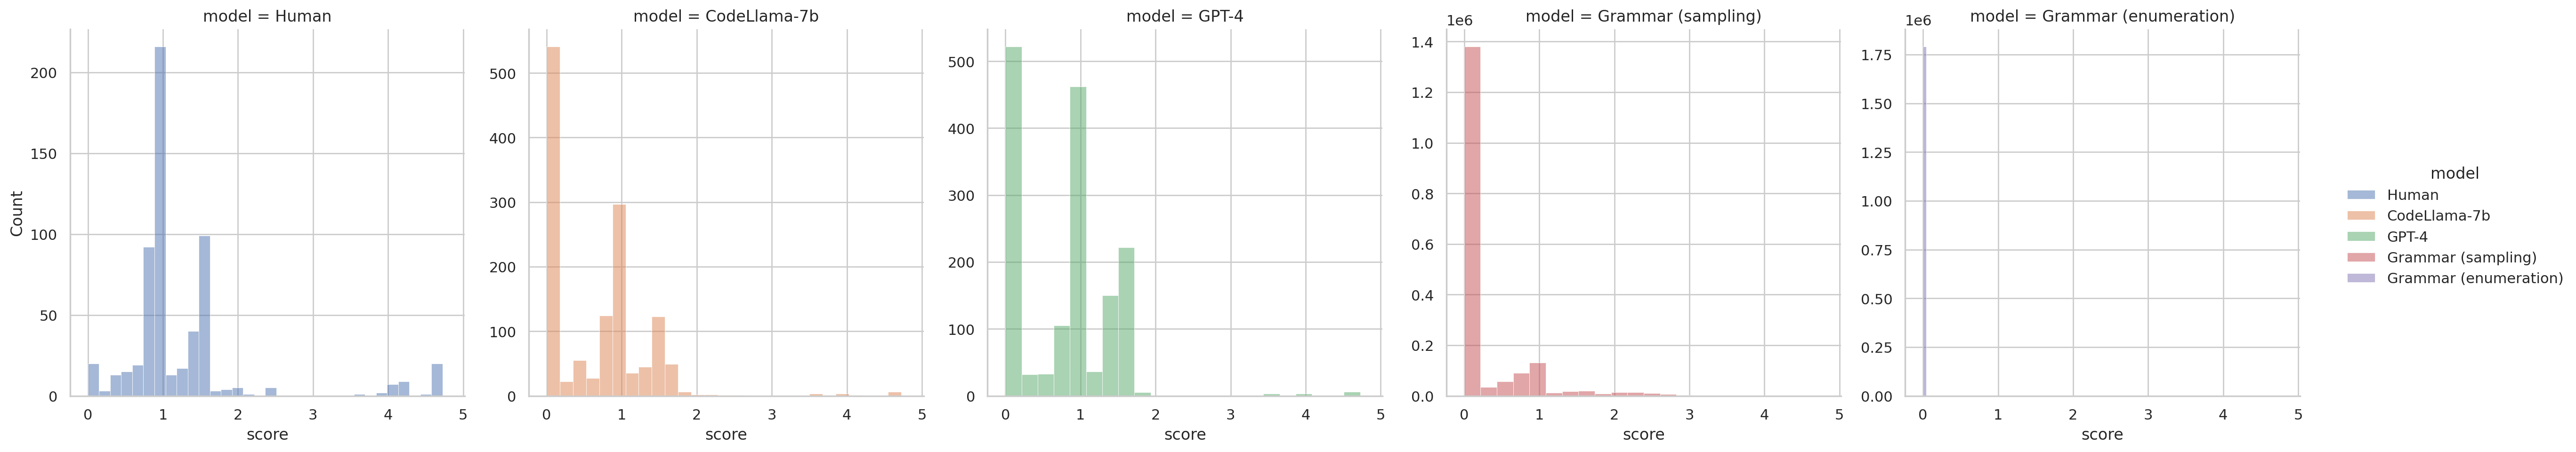

In [34]:
sns.displot(
    data=df_1,
    col="model",
    x="score",
    hue="model",
    common_norm=False,
    common_bins=False,
    facet_kws=dict(sharey=False)
)

### Grouped by trial

Text(0, 0.5, 'EIG')

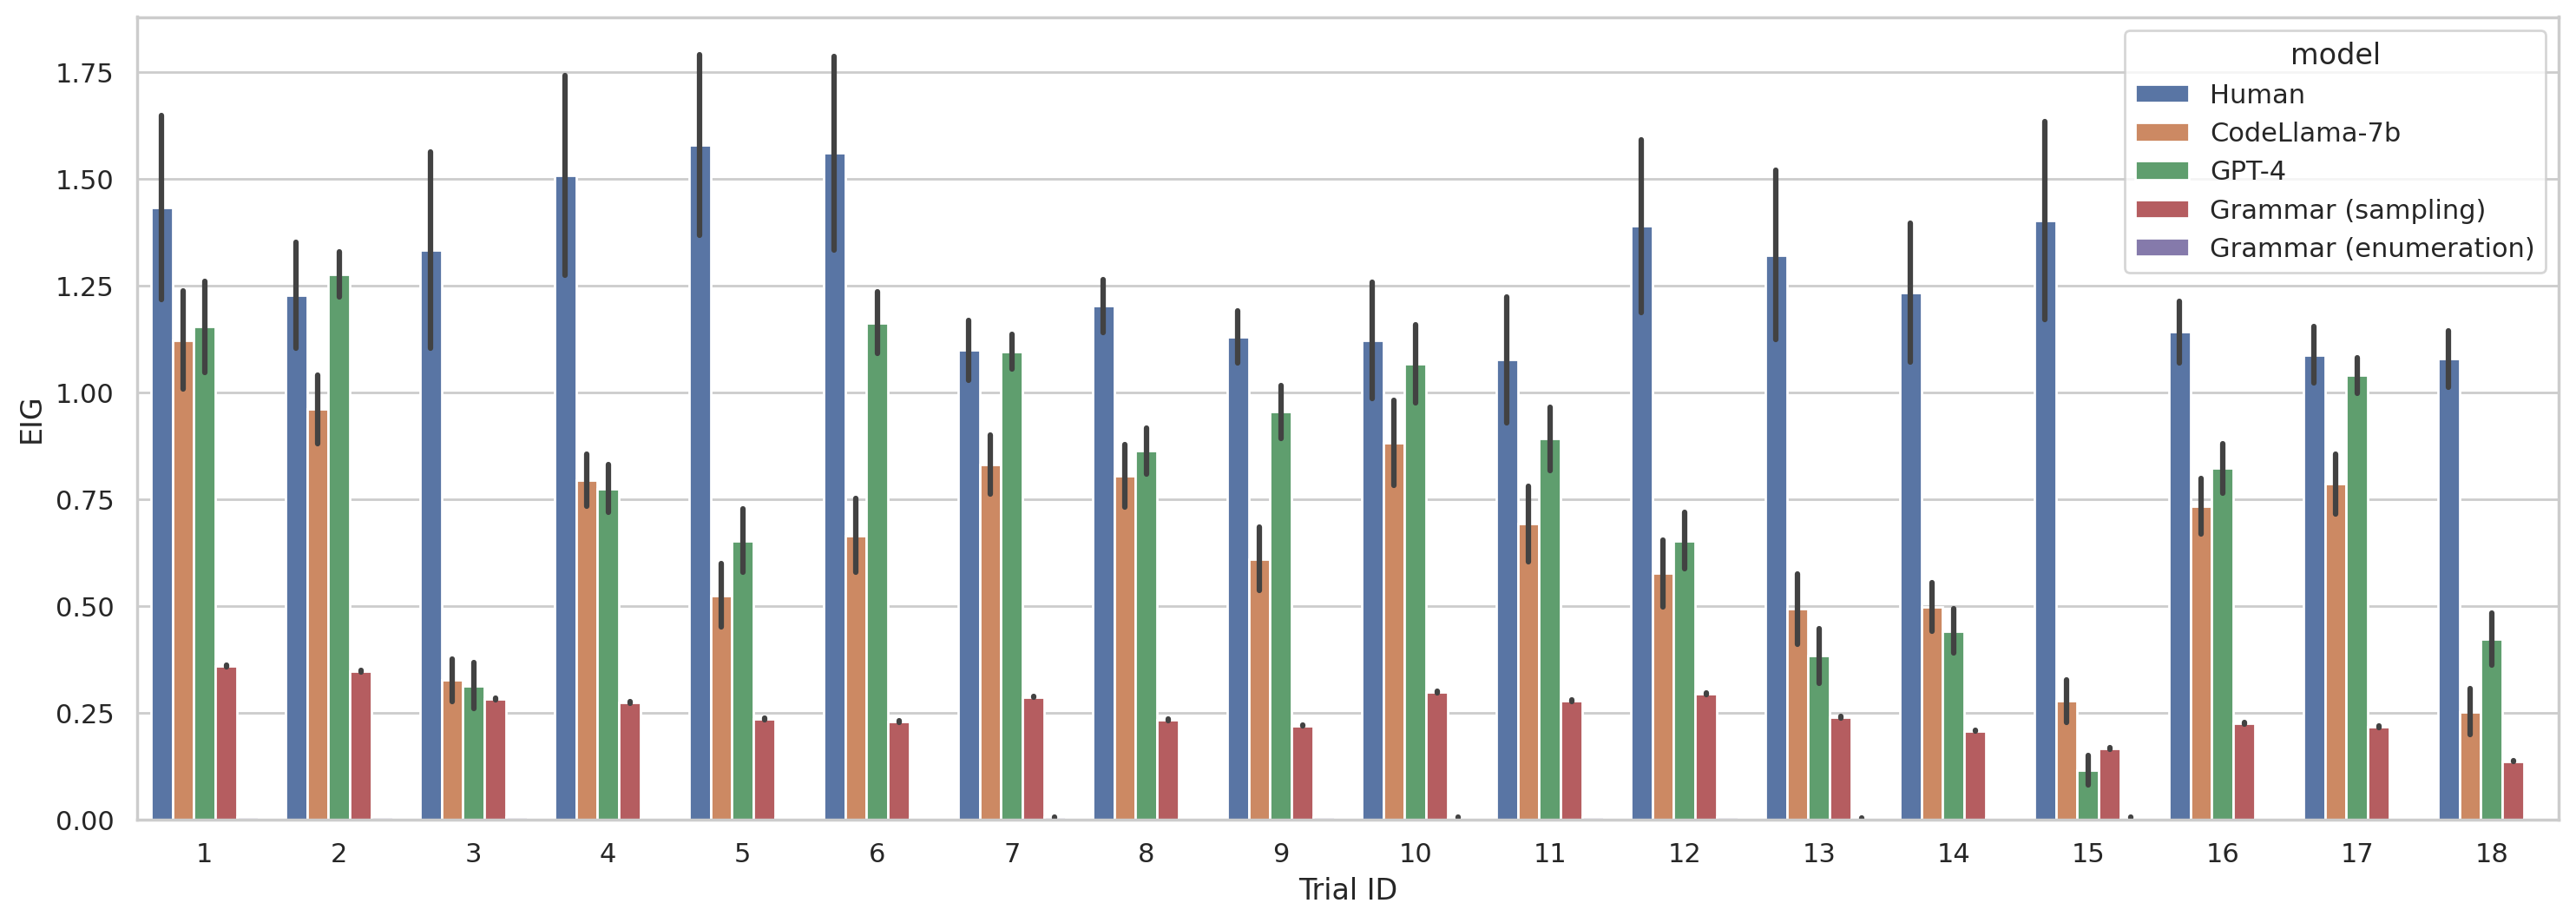

In [35]:
plt.figure(figsize=(18, 6))
sns.barplot(data=df_1, hue="model", x="trial_id", y="score", errorbar="se")
plt.xlabel("Trial ID")
plt.ylabel("EIG")

Text(0, 0.5, 'EIG')

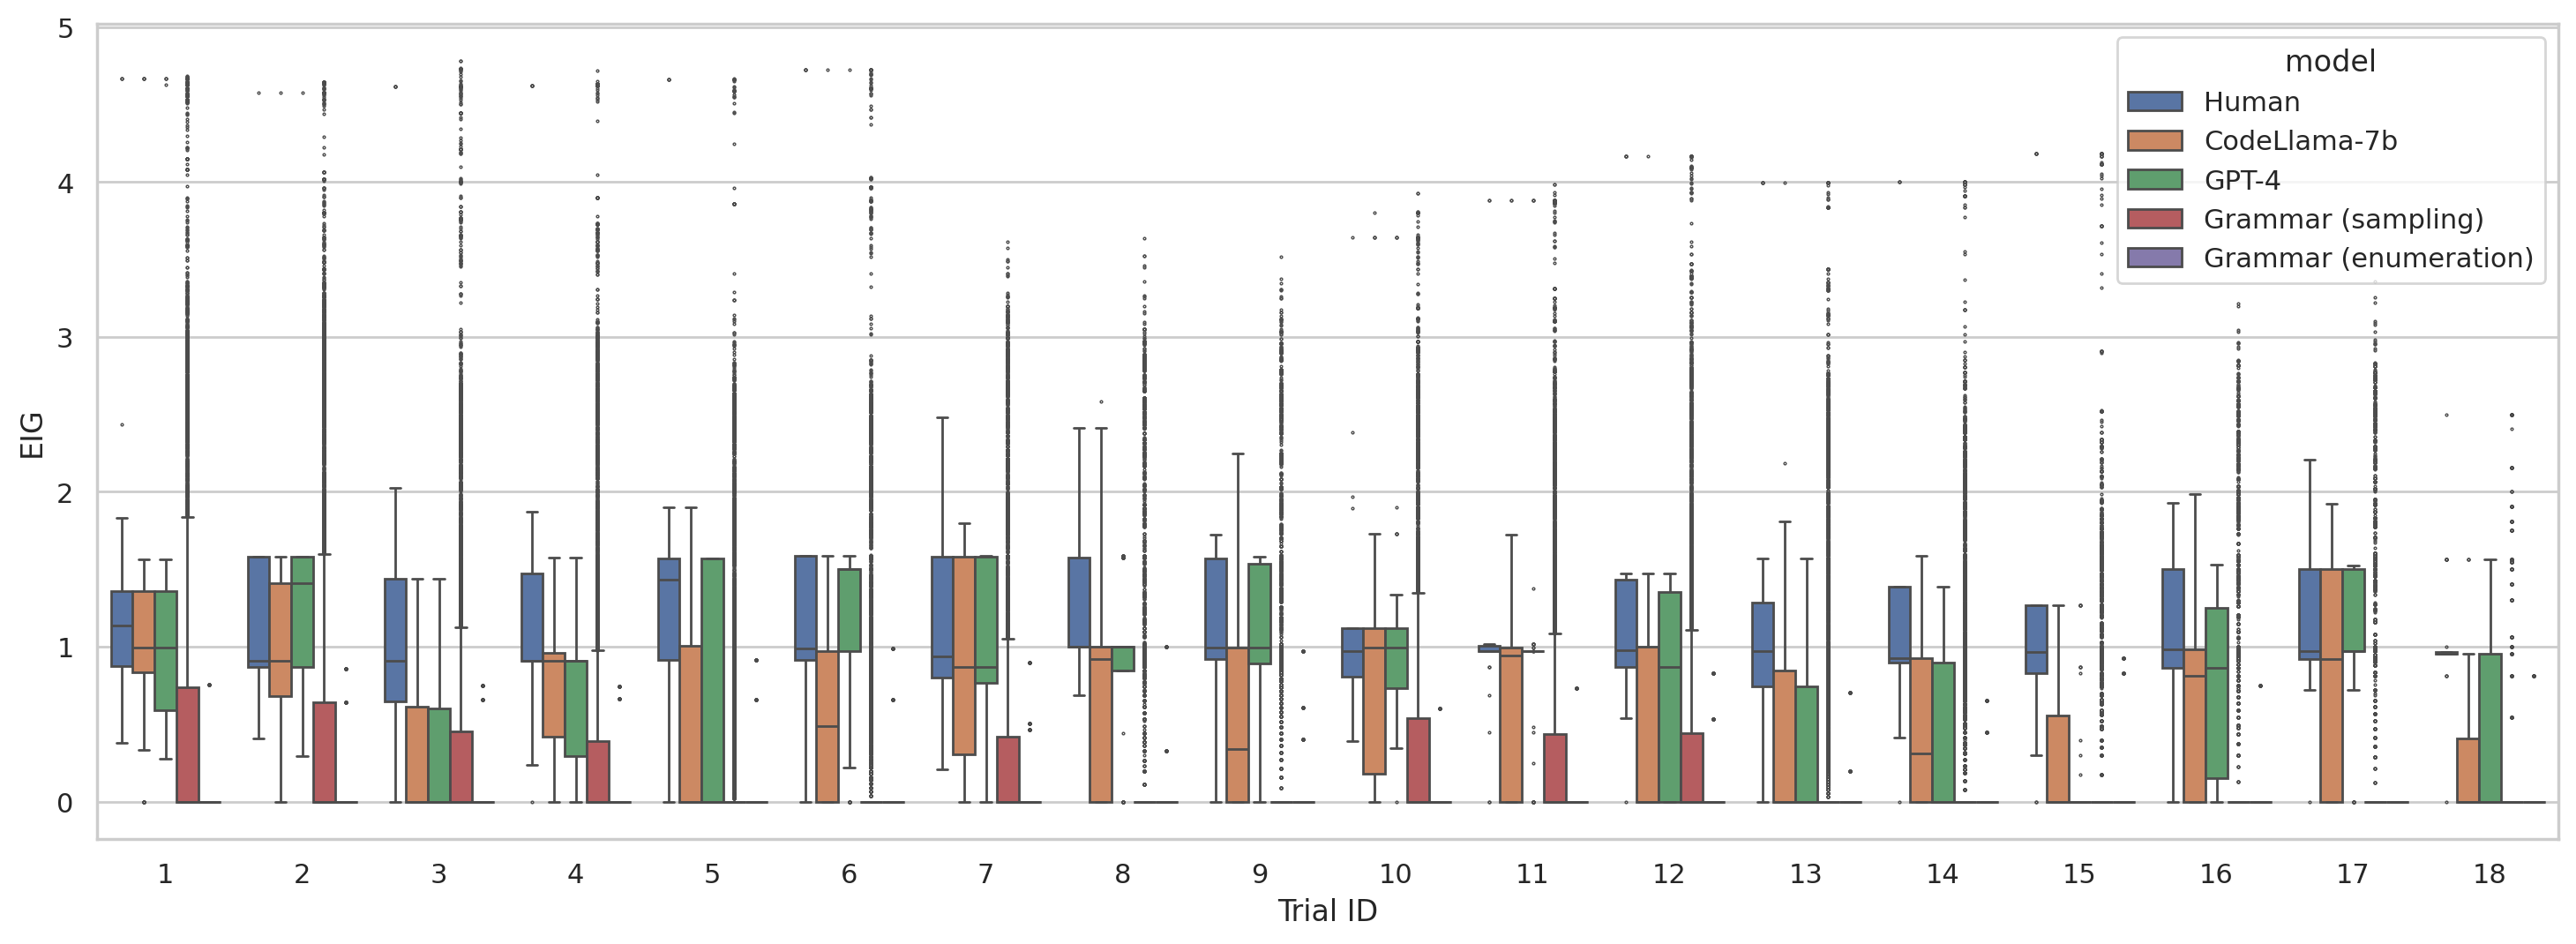

In [36]:
plt.figure(figsize=(18, 6))
# sns.boxplot(data=df, hue="model", x="trial_id", y="score", showfliers=False)
sns.boxplot(
    data=df_1,
    hue="model",
    x="trial_id",
    y="score",
    fliersize=1.0,
    flierprops={"marker": "."},
)
plt.xlabel("Trial ID")
plt.ylabel("EIG")

<Axes: xlabel='trial_id', ylabel='score'>

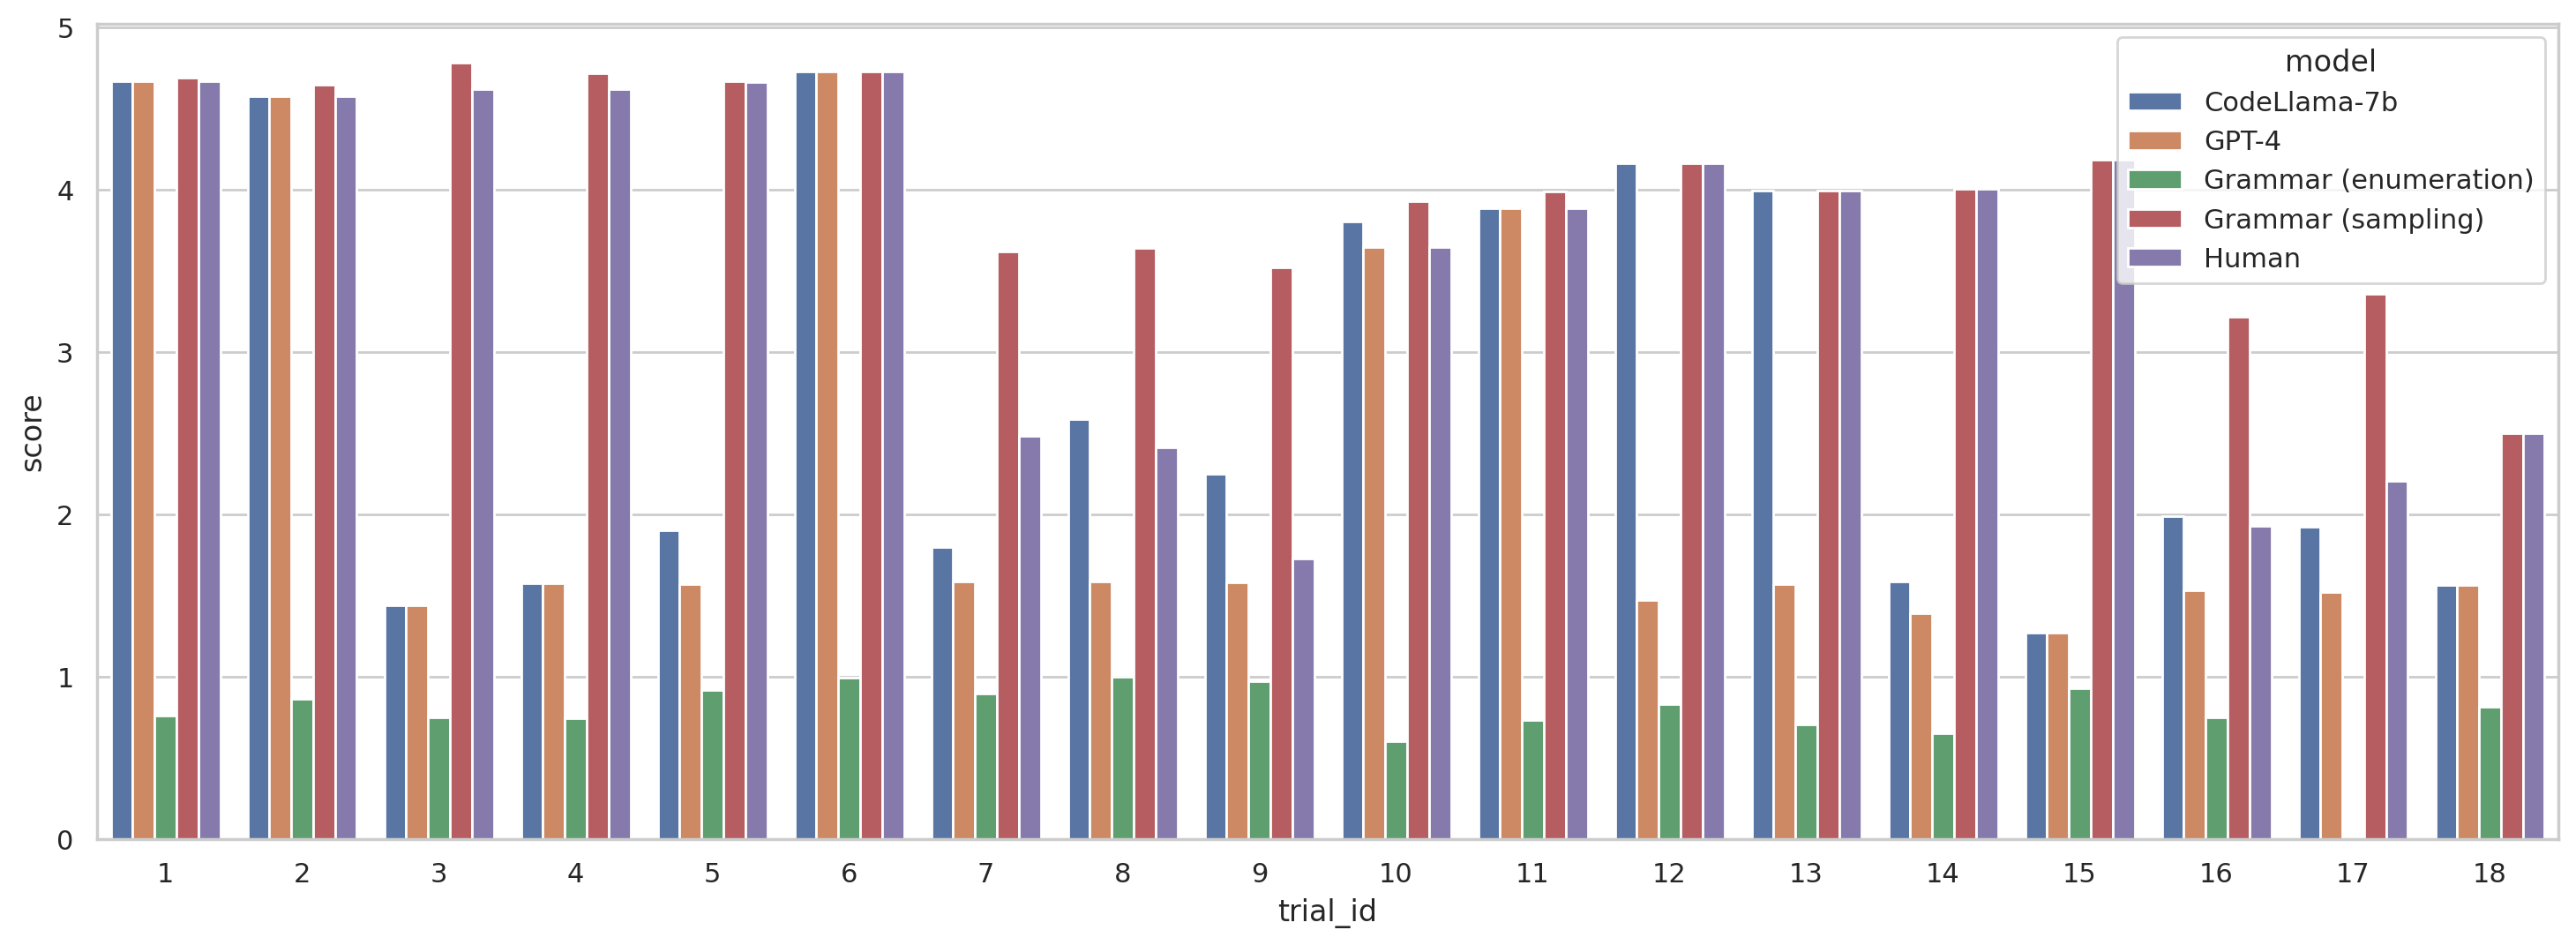

In [37]:
df_max = df_1.groupby(["model", "trial_id"]).score.agg("max")

plt.figure(figsize=(18, 6))
sns.barplot(data=df_max.reset_index(), x="trial_id", y="score", hue="model")

### EIG Percentile

Text(0, 0.5, 'EIG')

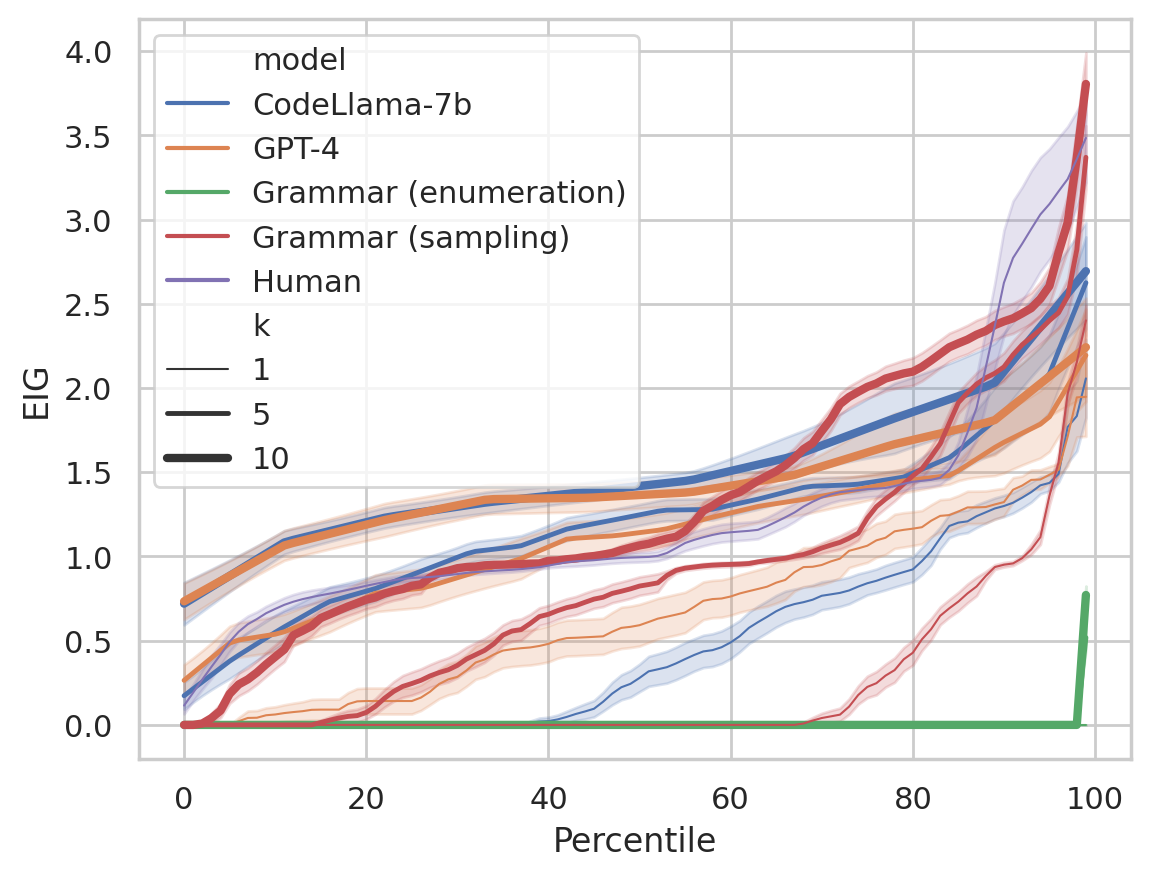

In [38]:
data = []

for (model, k, trial_id), df_group in df.groupby(["model", "k", "trial_id"]):
    scores = df_group.score.fillna(value=0).values
    for i in range(100):
        data.append(
            {
                "model": model,
                "k": k,
                "trial_id": trial_id,
                "percentile": i,
                "score": np.percentile(scores, i),
            }
        )

df_eig_sum = pd.DataFrame(data)

sns.lineplot(data=df_eig_sum[df_eig_sum["k"] <= 10], x="percentile", y="score", hue="model", size="k", errorbar="se")
plt.xlabel("Percentile")
plt.ylabel("EIG")

Text(0, 0.5, 'EIG')

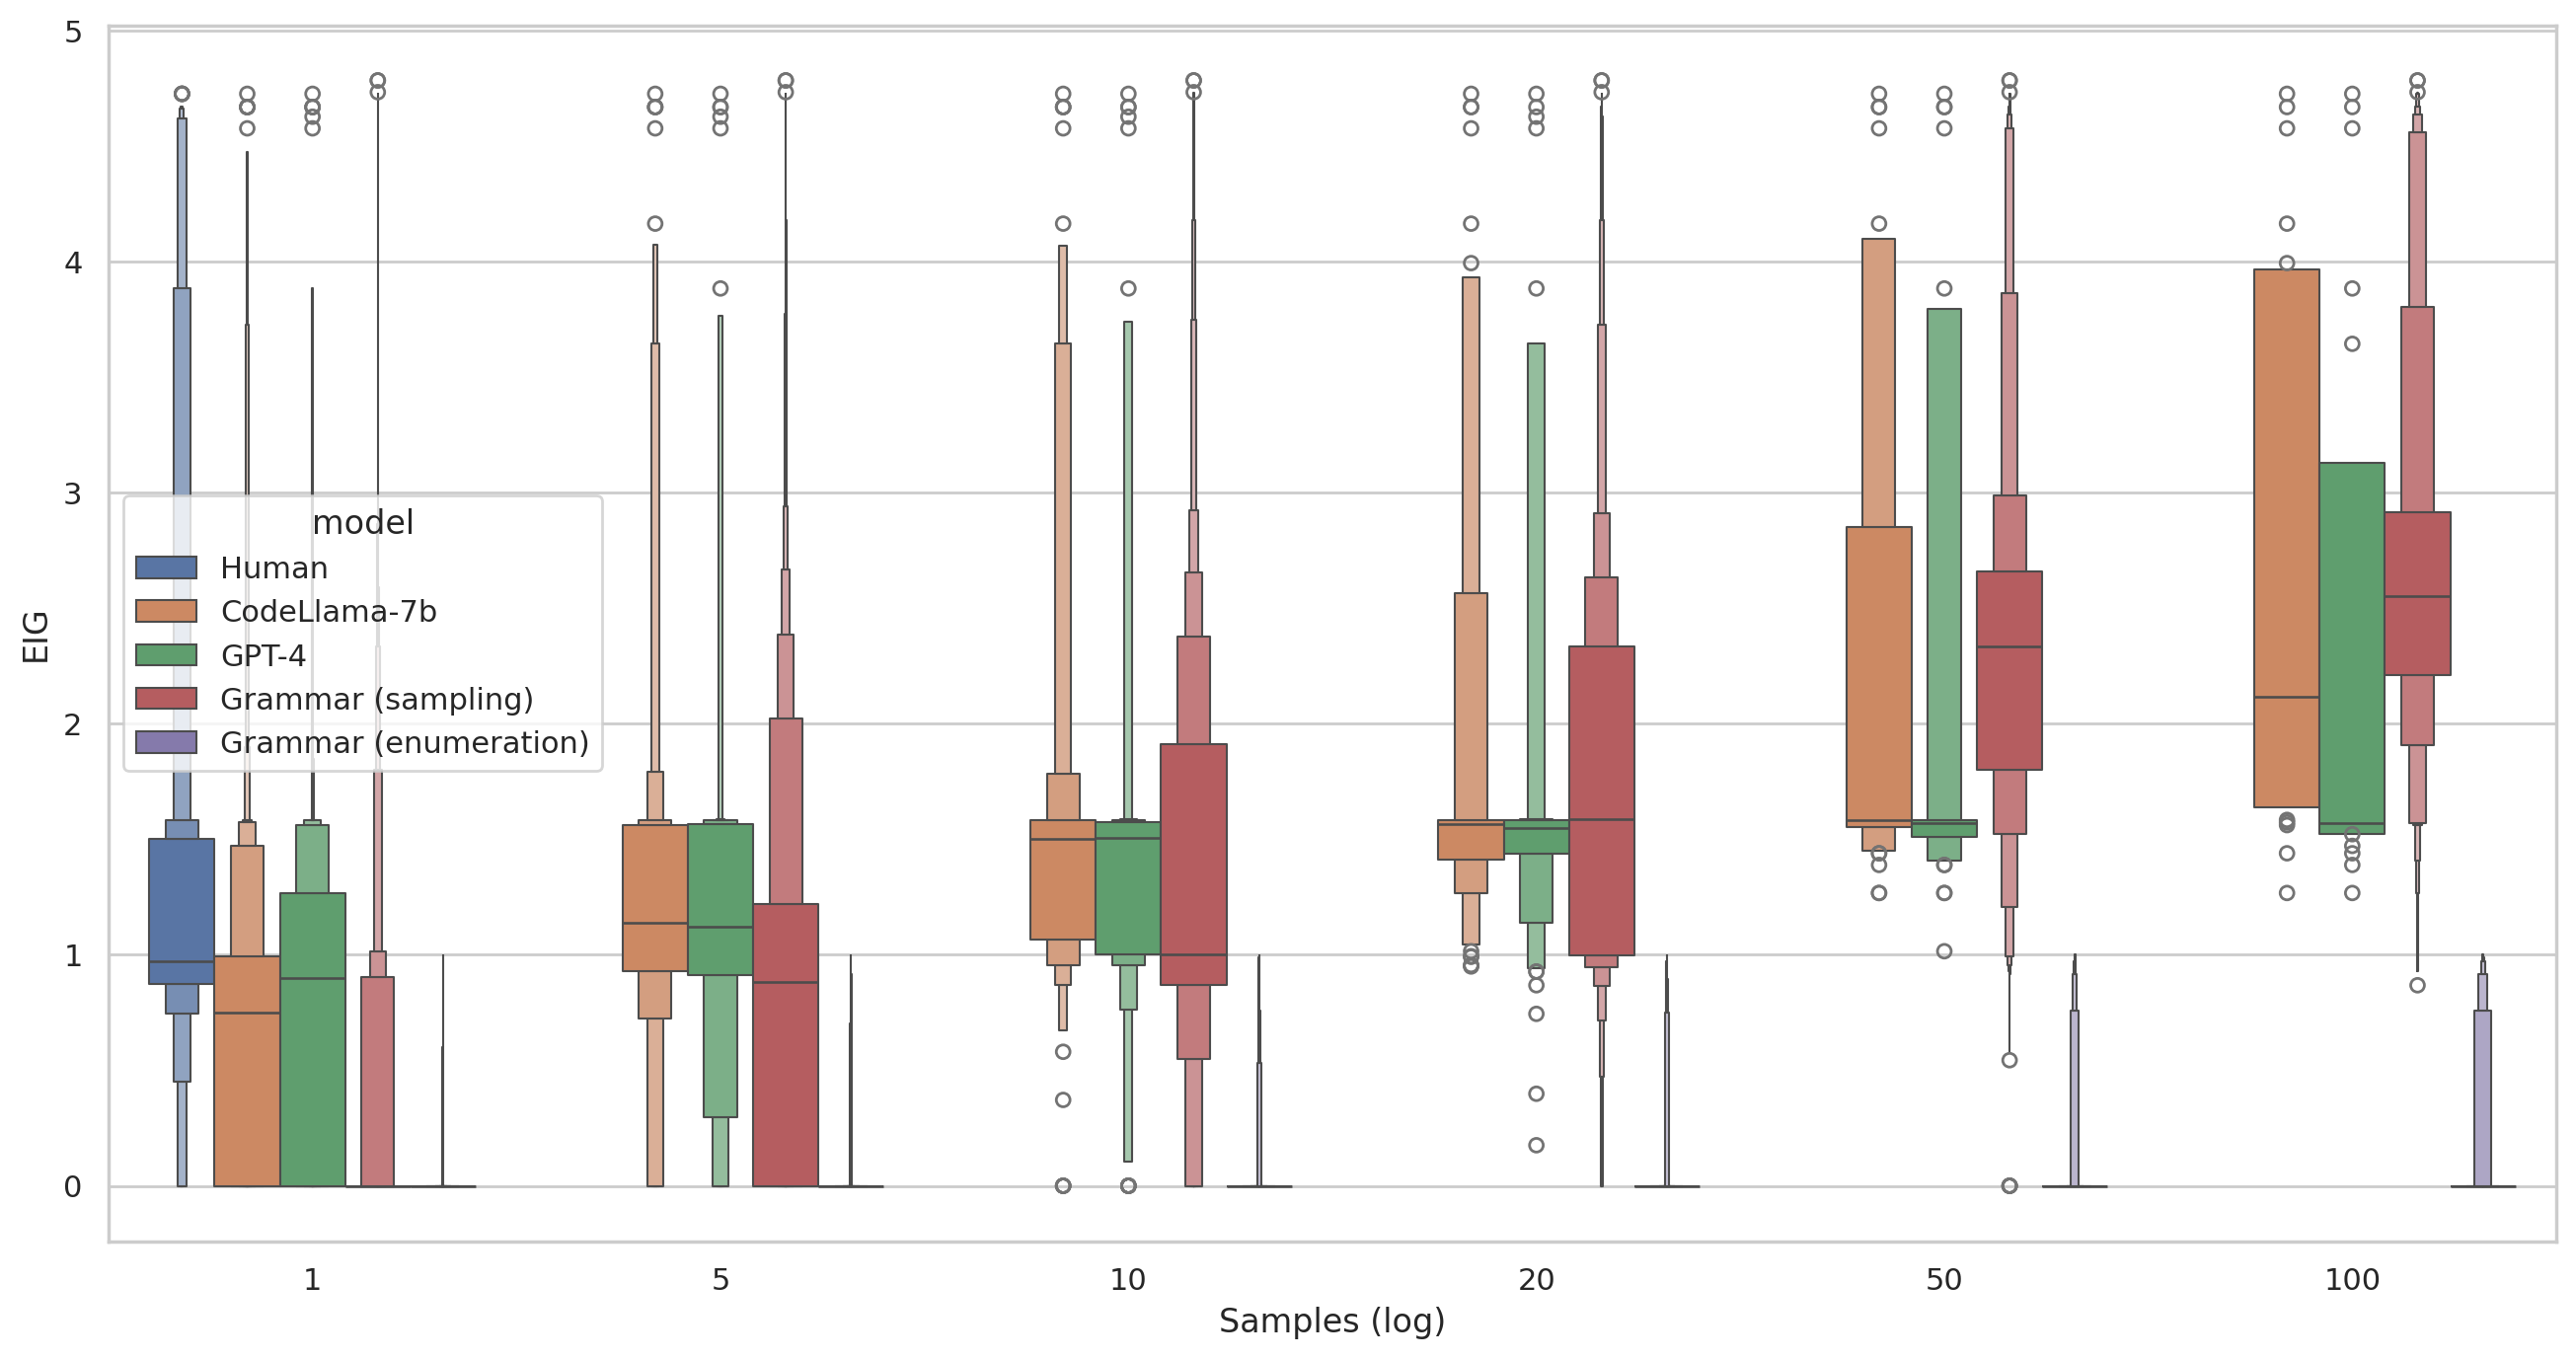

In [39]:
plt.figure(figsize=(16, 8))
# sns.pointplot(data=df, x="k", y="score", hue="model", errorbar="se")
sns.boxenplot(data=df, x="k", y="score", hue="model")
plt.xlabel("Samples (log)")
plt.ylabel("EIG")
# plt.xscale("log")